In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Admission_Predict_Ver1.1.csv to Admission_Predict_Ver1.1.csv


In [3]:
df = pd.read_csv("Admission_Predict_Ver1.1.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (500, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.columns = df.columns.str.strip()

df.columns = [
    "Serial_No",
    "GRE_Score",
    "TOEFL_Score",
    "University_Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    "Chance_of_Admit"
]

df.head()

,Serial_No,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial_No          500 non-null    int64  
 1   GRE_Score          500 non-null    int64  
 2   TOEFL_Score        500 non-null    int64  
 3   University_Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance_of_Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [7]:
df.describe()

,Serial_No,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Serial_No            0
GRE_Score            0
TOEFL_Score          0
University_Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance_of_Admit      0
dtype: int64


In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Serial_No            0
GRE_Score            0
TOEFL_Score          0
University_Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance_of_Admit      0
dtype: int64


In [10]:
X = df[
    [
        "GRE_Score",
        "TOEFL_Score",
        "University_Rating",
        "SOP",
        "LOR",
        "CGPA",
        "Research"
    ]
]

y = df["Chance_of_Admit"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Chance_of_Admit")

Features:
['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research']

Target:
Chance_of_Admit


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [12]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
------------------
MAE : 0.0427226542770537
RMSE: 0.06086588041578314
R²  : 0.8188432567829627


In [13]:
polynomial_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

polynomial_model.fit(X_train, y_train)

y_pred_poly = polynomial_model.predict(X_test)

poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("---------------------")
print("MAE :", poly_mae)
print("RMSE:", poly_rmse)
print("R²  :", poly_r2)

Polynomial Regression
---------------------
MAE : 0.04056563952167271
RMSE: 0.05956373640768617
R²  : 0.8265115552643365


In [14]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("----------------")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression
----------------
MAE : 0.04274719474628152
RMSE: 0.06087507177653933
R²  : 0.8187885396675396


In [15]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression")
print("----------------")
print("MAE :", lasso_mae)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)

Lasso Regression
----------------
MAE : 0.042510546595840755
RMSE: 0.06080880892435433
R²  : 0.8191828243130252


In [16]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        linear_mae,
        poly_mae,
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        linear_rmse,
        poly_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2 Score": [
        linear_r2,
        poly_r2,
        ridge_r2,
        lasso_r2
    ]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.042723,0.060866,0.818843
1,Polynomial Regression,0.040566,0.059564,0.826512
2,Ridge Regression,0.042747,0.060875,0.818789
3,Lasso Regression,0.042511,0.060809,0.819183


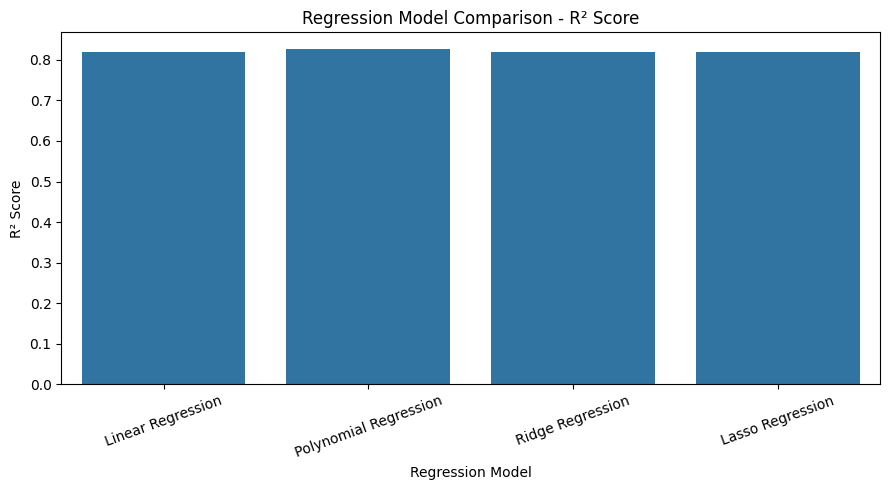

In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=regression_results,
    x="Model",
    y="R2 Score"
)

plt.title("Regression Model Comparison - R² Score")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [18]:
df["Admitted"] = (df["Chance_of_Admit"] >= 0.75).astype(int)

print(df["Admitted"].value_counts())

print("\nClass Distribution:")
print("0 = Not Admitted")
print("1 = Admitted")

Admitted
0    282
1    218
Name: count, dtype: int64

Class Distribution:
0 = Not Admitted
1 = Admitted


In [19]:
X_class = df[
    [
        "GRE_Score",
        "TOEFL_Score",
        "University_Rating",
        "SOP",
        "LOR",
        "CGPA",
        "Research"
    ]
]

y_class = df["Admitted"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training samples:", X_train_c.shape[0])
print("Testing samples:", X_test_c.shape[0])

Training samples: 400
Testing samples: 100


In [20]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train_c, y_train_c)

y_pred_logistic = logistic_model.predict(X_test_c)

logistic_accuracy = accuracy_score(y_test_c, y_pred_logistic)
logistic_precision = precision_score(y_test_c, y_pred_logistic)
logistic_recall = recall_score(y_test_c, y_pred_logistic)
logistic_f1 = f1_score(y_test_c, y_pred_logistic)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression
-------------------
Accuracy : 0.91
Precision: 0.926829268292683
Recall   : 0.8636363636363636
F1 Score : 0.8941176470588236


In [21]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train_c, y_train_c)

y_pred_knn = knn_model.predict(X_test_c)

knn_accuracy = accuracy_score(y_test_c, y_pred_knn)
knn_precision = precision_score(y_test_c, y_pred_knn)
knn_recall = recall_score(y_test_c, y_pred_knn)
knn_f1 = f1_score(y_test_c, y_pred_knn)

print("KNN Classification")
print("-------------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Classification
-------------------
Accuracy : 0.91
Precision: 0.9069767441860465
Recall   : 0.8863636363636364
F1 Score : 0.896551724137931


In [22]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall
    ],
    "F1 Score": [
        logistic_f1,
        knn_f1
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.91,0.926829,0.863636,0.894118
1,KNN,0.91,0.906977,0.886364,0.896552


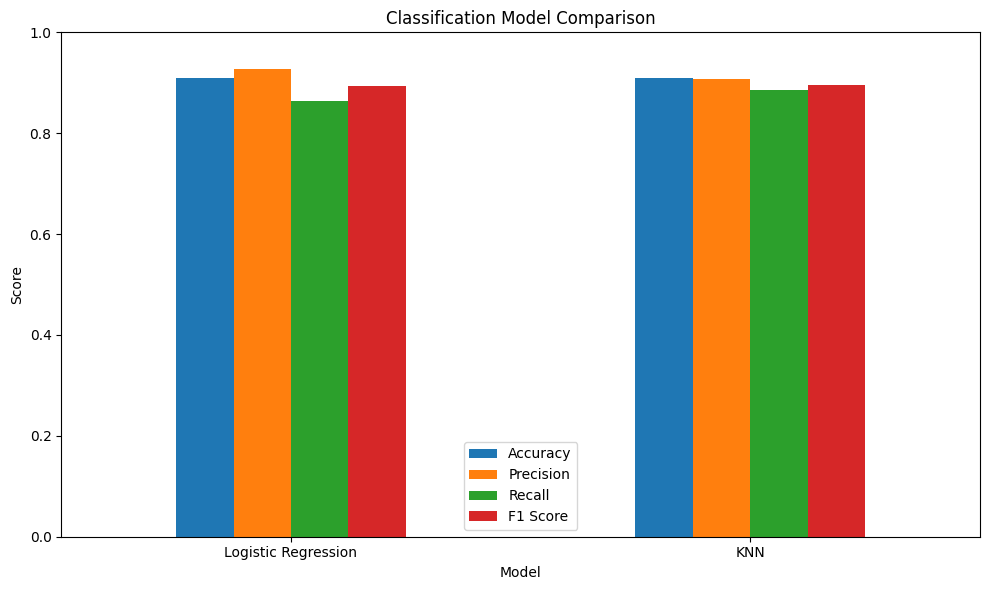

In [23]:
classification_results.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

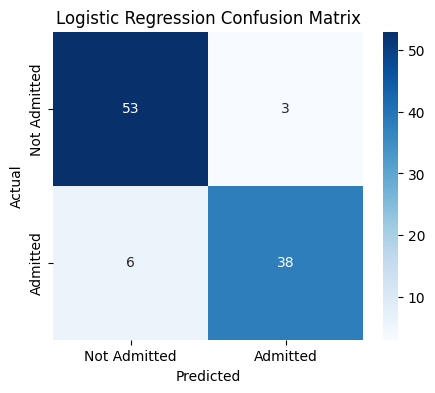

In [24]:
cm_logistic = confusion_matrix(
    y_test_c,
    y_pred_logistic
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Admitted", "Admitted"],
    yticklabels=["Not Admitted", "Admitted"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

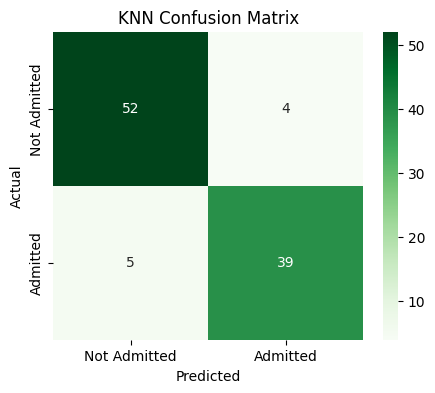

In [25]:
cm_knn = confusion_matrix(
    y_test_c,
    y_pred_knn
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Admitted", "Admitted"],
    yticklabels=["Not Admitted", "Admitted"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
print("Logistic Regression Classification Report")
print("------------------------------------------")
print(classification_report(y_test_c, y_pred_logistic))

print("\nKNN Classification Report")
print("-------------------------")
print(classification_report(y_test_c, y_pred_knn))

Logistic Regression Classification Report
------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        56
           1       0.93      0.86      0.89        44

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100


KNN Classification Report
-------------------------
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        56
           1       0.91      0.89      0.90        44

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



In [27]:
best_regression = regression_results.loc[
    regression_results["R2 Score"].idxmax(),
    "Model"
]

best_classification = classification_results.loc[
    classification_results["F1 Score"].idxmax(),
    "Model"
]

print("FINAL CONCLUSION")
print("================")
print()
print("Best Regression Model:", best_regression)
print("Best Classification Model:", best_classification)
print()
print("The project predicts the chance of graduate admission")
print("using academic and application-related features.")
print()
print("Regression models predict the continuous admission probability,")
print("while classification models predict whether the applicant is")
print("likely to be admitted or not.")

FINAL CONCLUSION

Best Regression Model: Polynomial Regression
Best Classification Model: KNN

The project predicts the chance of graduate admission
using academic and application-related features.

Regression models predict the continuous admission probability,
while classification models predict whether the applicant is
likely to be admitted or not.
